# Bar 차트

In [22]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib
import matplotlib.font_manager as fm



In [23]:
# 기본적인 설정
plt.rcParams["figure.figsize"] = [10,8]
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")
plt.rcParams['axes.unicode_minus'] = False

### 기본제공하는 tips dataset 불러오기

In [24]:
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [25]:
sum_tip_by_day = tips.groupby("day")["tip"].sum()
sum_tip_by_day

day
Thur    171.83
Fri      51.96
Sat     260.40
Sun     247.39
Name: tip, dtype: float64

In [26]:
x_label = ["Thu","Fri","Sat","Sun"]
x_label_index = np.arange(len(x_label))
x_label_index

array([0, 1, 2, 3])

<BarContainer object of 4 artists>

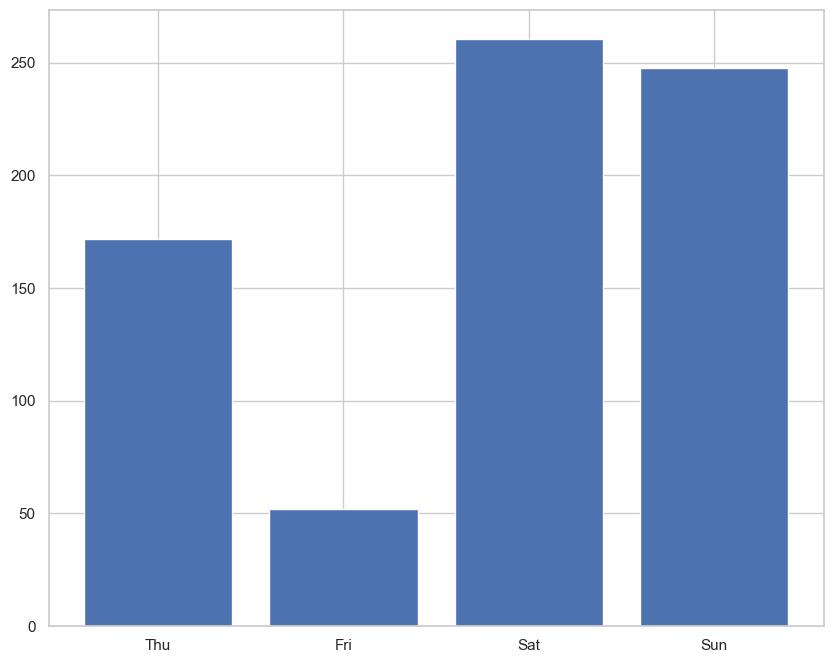

In [27]:
plt.bar(x_label,sum_tip_by_day)

### *사실 여기부터 노트북을 바꿔 중간에 조금 날라감..*
 *(Bar Chart Seaborn으로하는거, Pie 차트)* 

# Line 차트

### tips에 가상 시간 컬럼 추가!

In [28]:
sun_tips = tips[tips["day"] == "Sun"]
sun_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3
187,30.46,2.00,Male,Yes,Sun,Dinner,5
188,18.15,3.50,Female,Yes,Sun,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3


In [29]:
import datetime

In [30]:
today = datetime.date.today()
today

datetime.date(2025, 7, 23)

In [31]:
date = []
date.append(datetime.date.today())

for time in range(sun_tips.shape[0]-1):
        today += datetime.timedelta(1)
        date.append(today)

date


[datetime.date(2025, 7, 23),
 datetime.date(2025, 7, 24),
 datetime.date(2025, 7, 25),
 datetime.date(2025, 7, 26),
 datetime.date(2025, 7, 27),
 datetime.date(2025, 7, 28),
 datetime.date(2025, 7, 29),
 datetime.date(2025, 7, 30),
 datetime.date(2025, 7, 31),
 datetime.date(2025, 8, 1),
 datetime.date(2025, 8, 2),
 datetime.date(2025, 8, 3),
 datetime.date(2025, 8, 4),
 datetime.date(2025, 8, 5),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 7),
 datetime.date(2025, 8, 8),
 datetime.date(2025, 8, 9),
 datetime.date(2025, 8, 10),
 datetime.date(2025, 8, 11),
 datetime.date(2025, 8, 12),
 datetime.date(2025, 8, 13),
 datetime.date(2025, 8, 14),
 datetime.date(2025, 8, 15),
 datetime.date(2025, 8, 16),
 datetime.date(2025, 8, 17),
 datetime.date(2025, 8, 18),
 datetime.date(2025, 8, 19),
 datetime.date(2025, 8, 20),
 datetime.date(2025, 8, 21),
 datetime.date(2025, 8, 22),
 datetime.date(2025, 8, 23),
 datetime.date(2025, 8, 24),
 datetime.date(2025, 8, 25),
 datetime.date(2025, 8,

In [32]:
sun_tips["date"] = date
sun_tips

,total_bill,tip,sex,smoker,day,time,size,date
0,16.99,1.01,Female,No,Sun,Dinner,2,2025-07-23
1,10.34,1.66,Male,No,Sun,Dinner,3,2025-07-24
2,21.01,3.50,Male,No,Sun,Dinner,3,2025-07-25
3,23.68,3.31,Male,No,Sun,Dinner,2,2025-07-26
4,24.59,3.61,Female,No,Sun,Dinner,4,2025-07-27
...,...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3,2025-10-02
187,30.46,2.00,Male,Yes,Sun,Dinner,5,2025-10-03
188,18.15,3.50,Female,Yes,Sun,Dinner,3,2025-10-04
189,23.10,4.00,Male,Yes,Sun,Dinner,3,2025-10-05


## Matplotlib으로 시각화

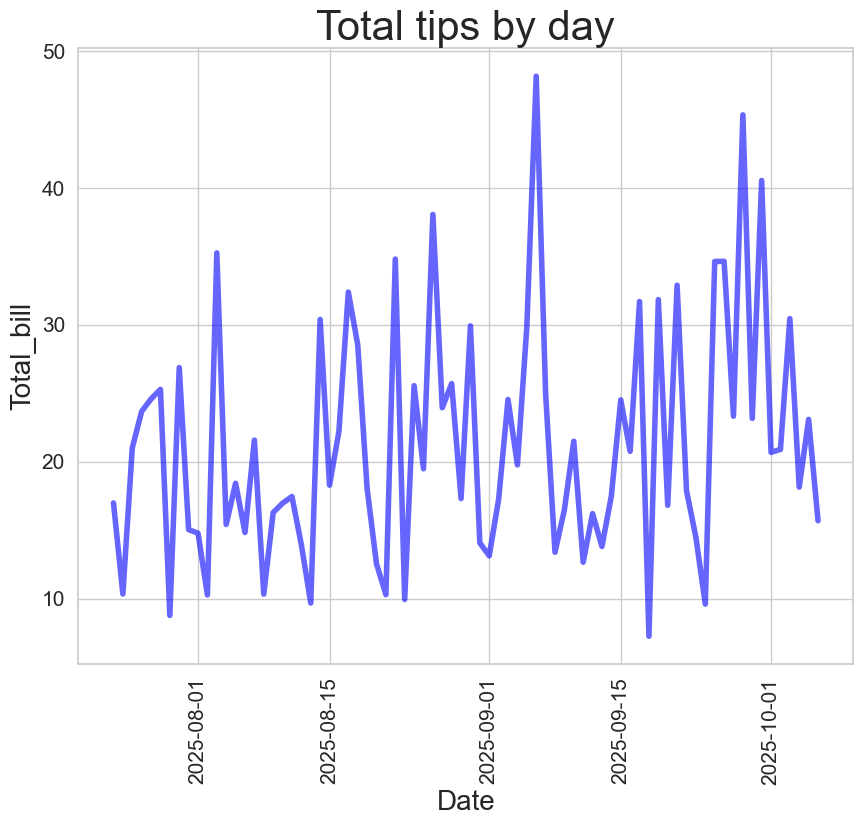

In [33]:
plt.plot(sun_tips["date"], sun_tips["total_bill"],
             linestyle="-",
             linewidth=4,
             color="blue",
             alpha=0.6)
plt.title("Total tips by day", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Total_bill", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Seaborn으로 시각화

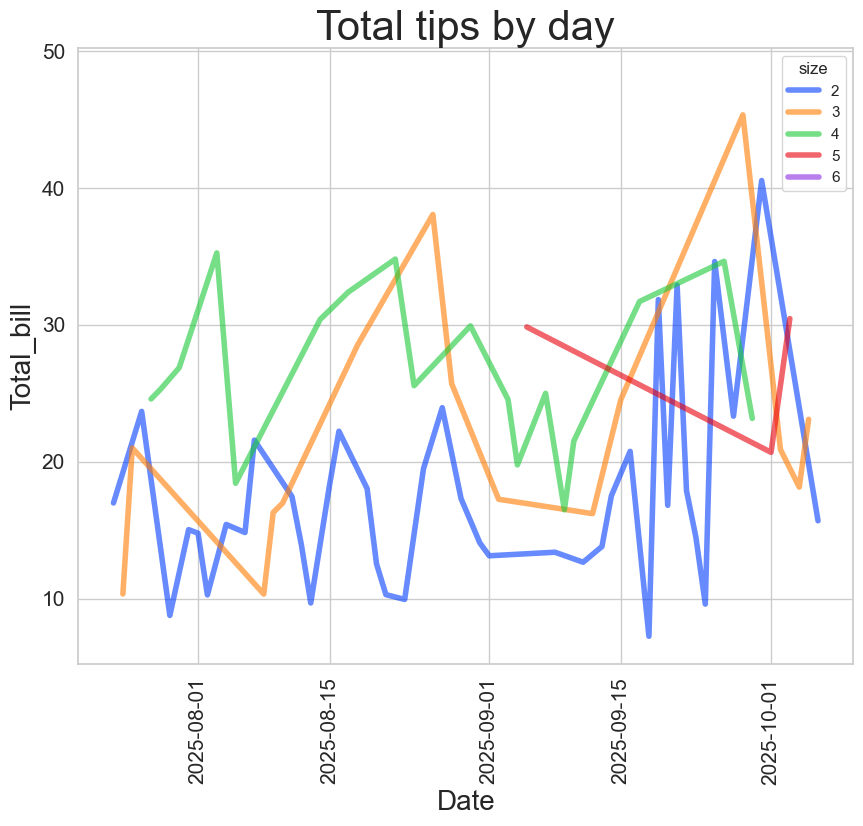

In [34]:
sns.lineplot(data=sun_tips,
                    x="date",
                    y="total_bill",
                    hue="size",
                    linewidth=4,
                    alpha=0.6,
                    palette="bright")
plt.title("Total tips by day", fontsize=30)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Total_bill", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.show()